# OMI Real Estate Quotations — Exploratory Analysis

This notebook builds a reproducible analytical dataset from the semiannual **OMI (Osservatorio del Mercato Immobiliare)** quotations published by the *Agenzia delle Entrate*.

**Source:** Agenzia delle Entrate — Osservatorio del Mercato Immobiliare.


## 1. Setup

The notebook keeps the analytical stack lightweight: `pandas` for data preparation, `numpy` for numerical transformations and `matplotlib` for visualization. The project root is resolved from the notebook location so the code does not depend on a specific working directory.


In [3]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'data').exists():
    PROJECT_ROOT = Path.cwd().parent

RAW_DIR = PROJECT_ROOT / 'data' / 'raw' / 'quotations'

## 2. Load and consolidate the raw OMI releases

OMI quotations are supplied as one semicolon-separated CSV per semester. Each file is loaded independently so that unexpected files can be identified early and the reference period is retained explicitly.


## 3. Initial dataset inspection

Inspect the schema, temporal coverage and raw structure before changing any values.


In [4]:
omi = pd.read_parquet(
    PROJECT_ROOT / "data" / "processed" / "omi_quotations.parquet"
)

print(f"Number of rows: {omi.shape[0]}")
omi.head()

Number of rows: 7516495


,Area_territoriale,Regione,Prov,Comune_ISTAT,Comune_cat,Sez,Comune_amm,Comune_descrizione,Fascia,Zona,...,reference_year,reference_semester,reference_period,reference_date,Compr_mid,Loc_mid,Compr_spread,Loc_spread,Compr_spread_pct,Loc_spread_pct
0,SUD,ABRUZZO,AQ,13066001.0,N1AB,NaN,A018,ACCIANO,B,B1,...,2004,S1,2004-S1,2004-06-30,395.0,NaN,150.0,NaN,37.974684,NaN
1,SUD,ABRUZZO,AQ,13066001.0,N1AB,NaN,A018,ACCIANO,B,B1,...,2004,S1,2004-S1,2004-06-30,325.0,1.0,130.0,NaN,40.000000,NaN
2,SUD,ABRUZZO,AQ,13066001.0,N1AB,NaN,A018,ACCIANO,B,B1,...,2004,S1,2004-S1,2004-06-30,325.0,1.0,130.0,NaN,40.000000,NaN
3,SUD,ABRUZZO,AQ,13066001.0,N1AB,NaN,A018,ACCIANO,B,B1,...,2004,S1,2004-S1,2004-06-30,210.0,1.0,80.0,NaN,38.095238,NaN
4,SUD,ABRUZZO,AQ,13066001.0,N1AB,NaN,A018,ACCIANO,B,B1,...,2004,S1,2004-S1,2004-06-30,85.0,NaN,30.0,NaN,35.294118,NaN


## 4. Data Exploration


<Axes: xlabel='Descr_Tipologia'>

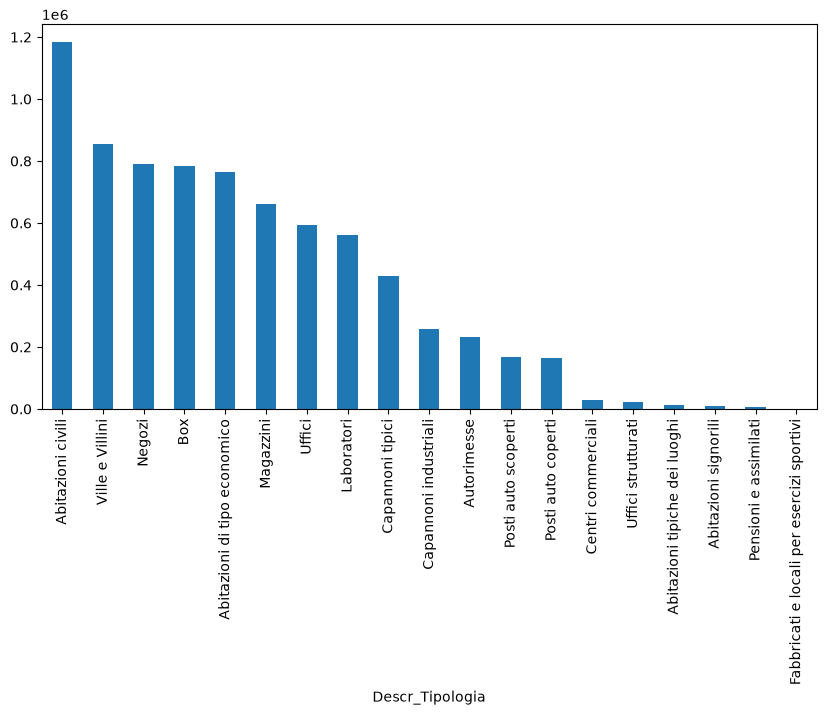

In [5]:
omi["Descr_Tipologia"].value_counts().plot(kind="bar", figsize=(10, 5))

### Residential property descriptions

In [6]:
residential_mask = omi['Descr_Tipologia'].astype('string').str.contains('abitazion|villa', case=False, na=False)
residential = omi.loc[residential_mask].copy()
print(f'Residential observations: {len(residential):,}')

Residential observations: 1,971,694


#### National Trend

In [7]:
national_trend = (
    residential.groupby('reference_date', as_index=False)
    .agg(median_compr_mid=('Compr_mid','median'), mean_compr_mid=('Compr_mid','mean'), observations=('Compr_mid','count'))
)

display(national_trend.tail(10))

,reference_date,median_compr_mid,mean_compr_mid,observations
34,2021-06-30,900.0,1087.043634,44323
35,2021-12-31,900.0,1084.901347,44550
36,2022-06-30,895.0,1086.832873,44568
37,2022-12-31,895.0,1091.734147,44581
38,2023-06-30,895.0,1096.249776,44622
39,2023-12-31,895.0,1099.863701,44663
40,2024-06-30,890.0,1102.279793,44583
41,2024-12-31,890.0,1107.890620,44327
42,2025-06-30,900.0,1115.333657,44342
43,2025-12-31,900.0,1124.300717,44349


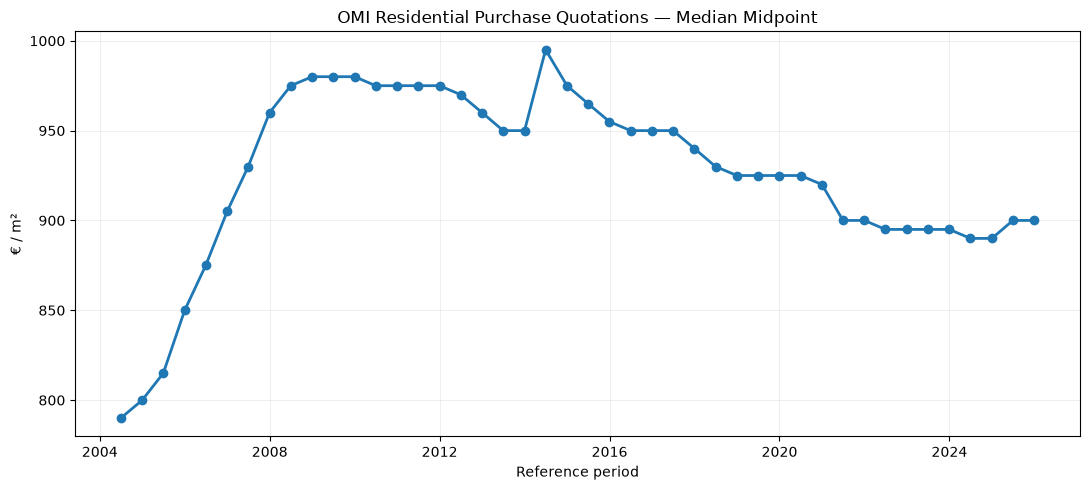

In [8]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(national_trend['reference_date'], national_trend['median_compr_mid'], marker='o', linewidth=2)
ax.set_title('OMI Residential Purchase Quotations — Median Midpoint')
ax.set_xlabel('Reference period')
ax.set_ylabel('€ / m²')
ax.grid(alpha=0.2)
fig.tight_layout()
plt.show()

#### Regional Inspection


In [9]:
regional_trend = (
    residential.groupby(['reference_date', "Regione"], as_index=False)
    .agg(median_compr_mid=('Compr_mid','median'), mean_compr_mid=('Compr_mid','mean'), observations=('Compr_mid','count'))
)

display(regional_trend.tail(10))

,reference_date,Regione,median_compr_mid,mean_compr_mid,observations
870,2025-12-31,MOLISE,425.00,504.259962,527
871,2025-12-31,PIEMONTE,765.00,890.331683,4545
872,2025-12-31,PUGLIA,765.00,900.528933,1659
873,2025-12-31,SARDEGNA,725.00,997.329218,1215
874,2025-12-31,SICILIA,571.25,667.302383,2644
875,2025-12-31,TOSCANA,1250.00,1431.282051,1911
876,2025-12-31,TRENTINO-ALTO ADIGE,2150.00,2370.805471,1645
877,2025-12-31,UMBRIA,725.00,761.482906,585
878,2025-12-31,VALLE D'AOSTA/VALLE`E D'AOSTE,1275.00,1652.770833,480
879,2025-12-31,VENETO,1125.00,1246.821901,3178


##### Top 10

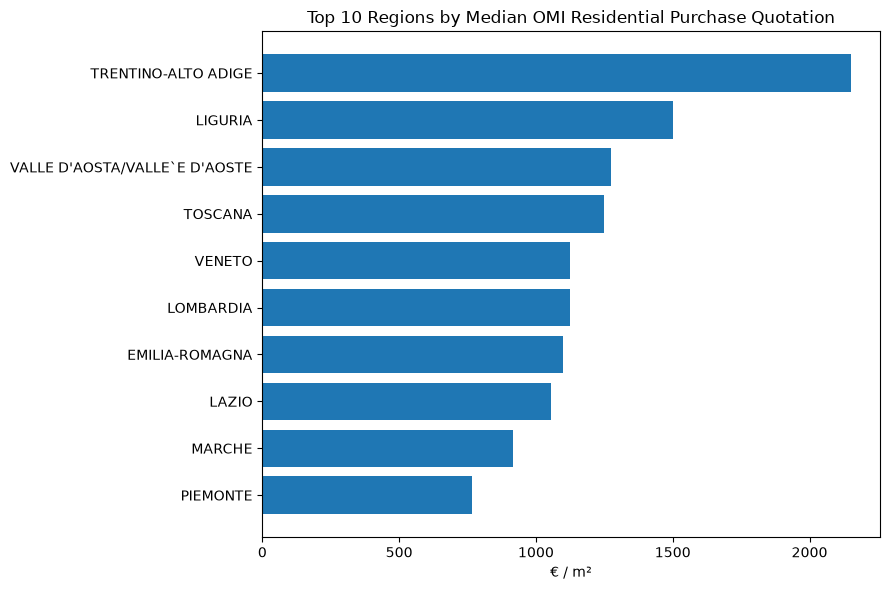

In [10]:
latest_date = regional_trend['reference_date'].max()

top_regions = (
    regional_trend[
        regional_trend['reference_date'].eq(latest_date)
    ]
    .nlargest(10, 'median_compr_mid')
    .sort_values('median_compr_mid')
)

fig, ax = plt.subplots(figsize=(9, 6))

ax.barh(
    top_regions['Regione'],
    top_regions['median_compr_mid']
)

ax.set_title('Top 10 Regions by Median OMI Residential Purchase Quotation')
ax.set_xlabel('€ / m²')
ax.set_ylabel('')

fig.tight_layout()
plt.show()

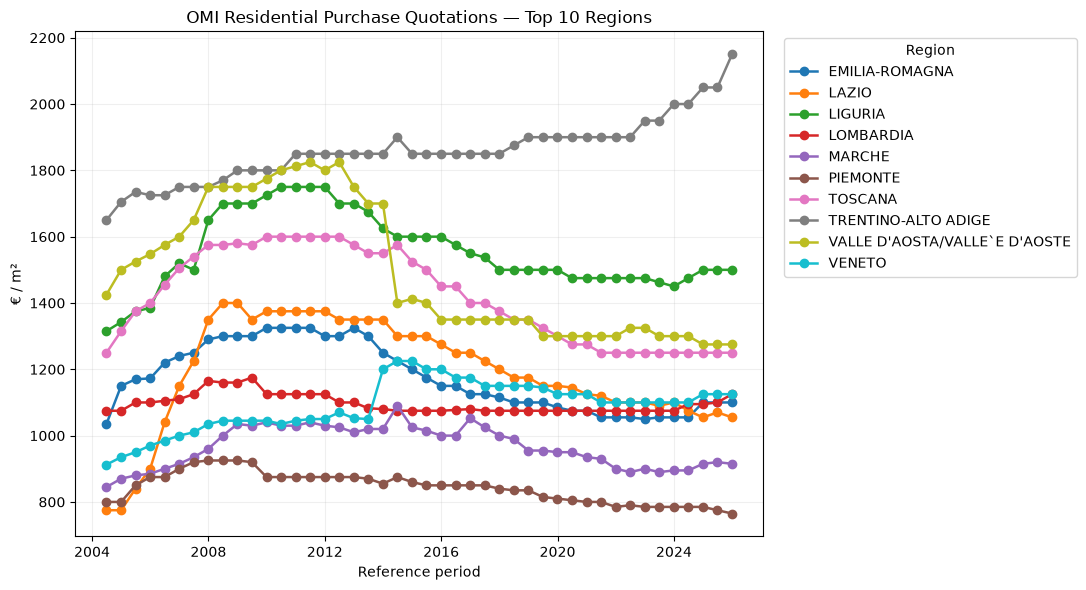

In [11]:
latest_date = regional_trend['reference_date'].max()

top_regions = (
    regional_trend[regional_trend['reference_date'].eq(latest_date)]
    .nlargest(10, 'median_compr_mid')['Regione']
)

plot_data = regional_trend[
    regional_trend['Regione'].isin(top_regions)
]

fig, ax = plt.subplots(figsize=(11, 6))

for regione, data in plot_data.groupby('Regione'):
    ax.plot(
        data['reference_date'],
        data['median_compr_mid'],
        marker='o',
        linewidth=1.8,
        label=regione
    )

ax.set_title('OMI Residential Purchase Quotations — Top 10 Regions')
ax.set_xlabel('Reference period')
ax.set_ylabel('€ / m²')

ax.grid(alpha=0.2)
ax.legend(
    title='Region',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

fig.tight_layout()
plt.show()

##### Last 10

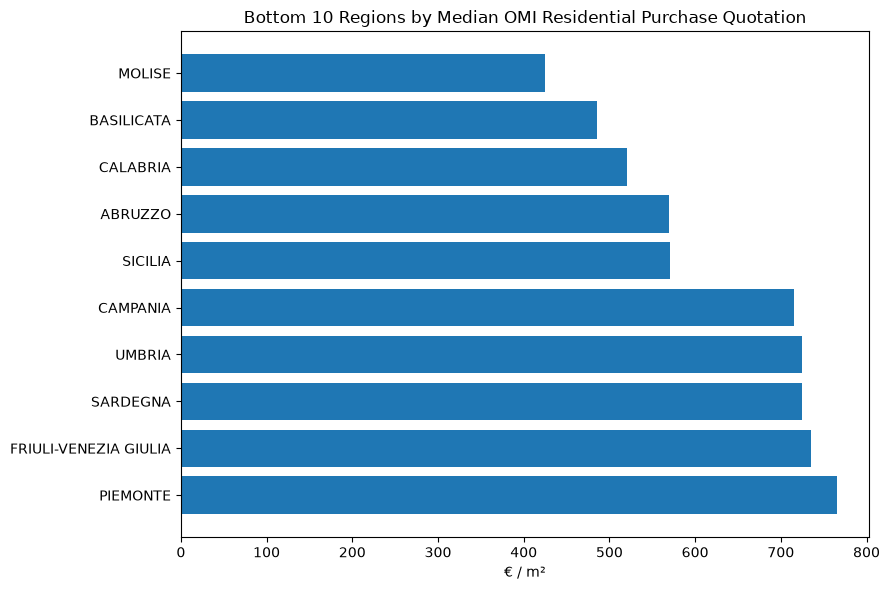

In [12]:
latest_date = regional_trend['reference_date'].max()

last_regions = (
    regional_trend[
        regional_trend['reference_date'].eq(latest_date)
    ]
    .nsmallest(10, 'median_compr_mid')
    .sort_values('median_compr_mid', ascending=False)
)

fig, ax = plt.subplots(figsize=(9, 6))

ax.barh(
    last_regions['Regione'],
    last_regions['median_compr_mid']
)

ax.set_title('Bottom 10 Regions by Median OMI Residential Purchase Quotation')
ax.set_xlabel('€ / m²')
ax.set_ylabel('')

fig.tight_layout()

plt.show()

#### Provincial Inspection

In [13]:
provincial_trend = (
    residential
    .groupby(['reference_date', 'Prov'], as_index=False)
    .agg(
        median_compr_mid=('Compr_mid', 'median'),
        mean_compr_mid=('Compr_mid', 'mean'),
        observations=('Compr_mid', 'count')
    )
)

latest_date = provincial_trend['reference_date'].max()

##### Top 20

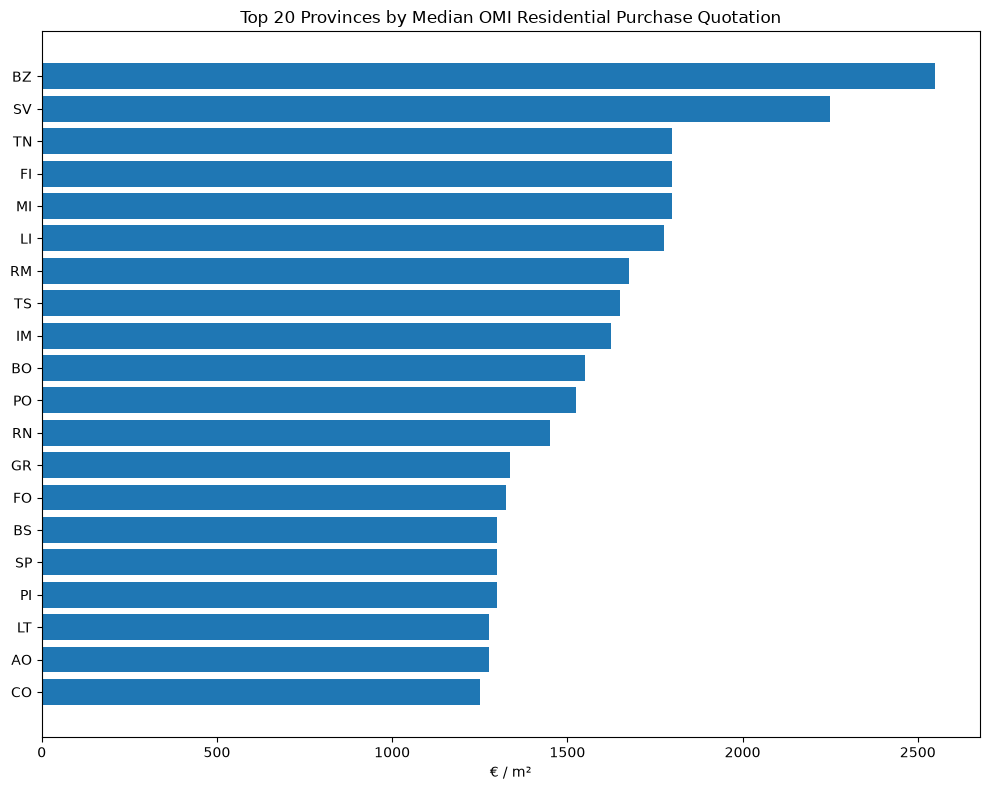

In [14]:
top_provinces = (
    provincial_trend[
        provincial_trend['reference_date'].eq(latest_date)
    ]
    .nlargest(20, 'median_compr_mid')
    .sort_values('median_compr_mid')
)

fig, ax = plt.subplots(figsize=(10, 8))

ax.barh(
    top_provinces['Prov'],
    top_provinces['median_compr_mid']
)

ax.set_title('Top 20 Provinces by Median OMI Residential Purchase Quotation')
ax.set_xlabel('€ / m²')
ax.set_ylabel('')

fig.tight_layout()

plt.show()

In [15]:
provincial_trend = (
    residential.groupby(['reference_date', "Prov"], as_index=False)
    .agg(median_compr_mid=('Compr_mid','median'), mean_compr_mid=('Compr_mid','mean'), observations=('Compr_mid','count'))
)

display(provincial_trend.tail(10))

,reference_date,Prov,median_compr_mid,mean_compr_mid,observations
4478,2025-12-31,TV,1150.00,1207.291221,467
4479,2025-12-31,UD,775.00,820.537736,530
4480,2025-12-31,VA,1200.00,1262.097458,472
4481,2025-12-31,VB,925.00,999.872774,393
4482,2025-12-31,VC,645.00,748.481675,191
4483,2025-12-31,VE,1250.00,1558.449304,503
4484,2025-12-31,VI,1150.00,1142.216809,821
4485,2025-12-31,VR,1177.50,1434.568750,400
4486,2025-12-31,VT,925.00,971.548117,239
4487,2025-12-31,VV,411.25,489.698795,166


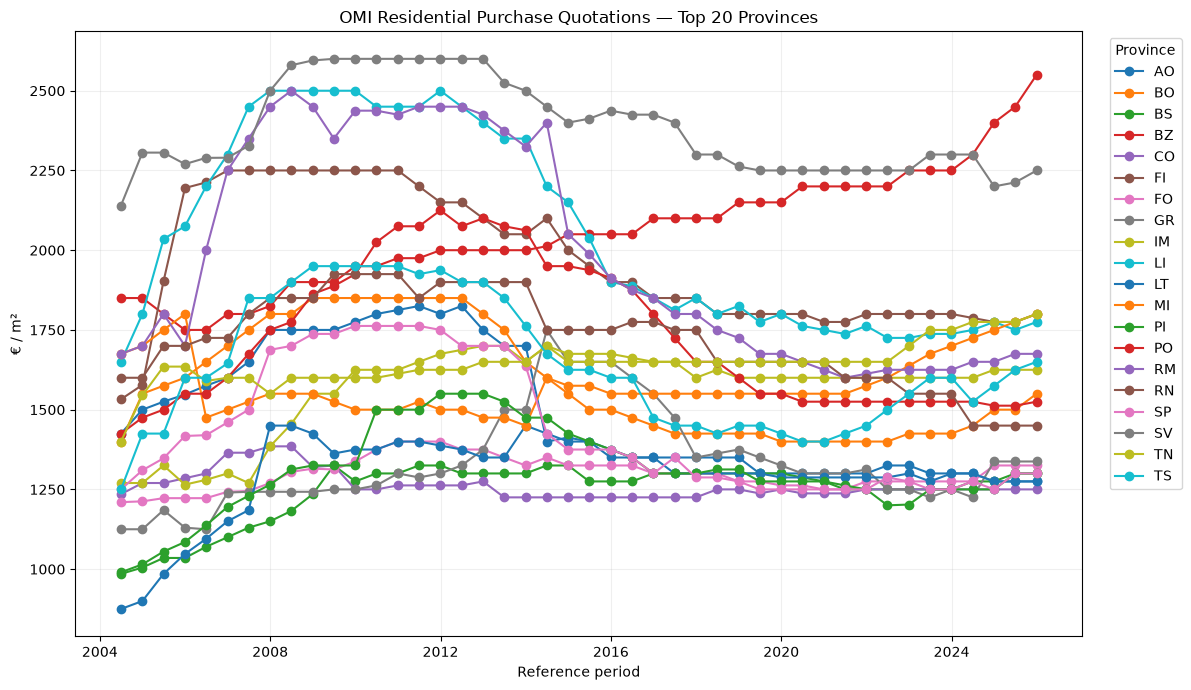

In [16]:
top_provinces_names = (
    provincial_trend[
        provincial_trend['reference_date'].eq(latest_date)
    ]
    .nlargest(20, 'median_compr_mid')['Prov']
)

plot_data = provincial_trend[
    provincial_trend['Prov'].isin(top_provinces_names)
]

fig, ax = plt.subplots(figsize=(12, 7))

for provincia, data in plot_data.groupby('Prov'):
    ax.plot(
        data['reference_date'],
        data['median_compr_mid'],
        marker='o',
        linewidth=1.5,
        label=provincia
    )

ax.set_title('OMI Residential Purchase Quotations — Top 20 Provinces')
ax.set_xlabel('Reference period')
ax.set_ylabel('€ / m²')
ax.grid(alpha=0.2)

ax.legend(
    title='Province',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

fig.tight_layout()

plt.show()

##### Last 20

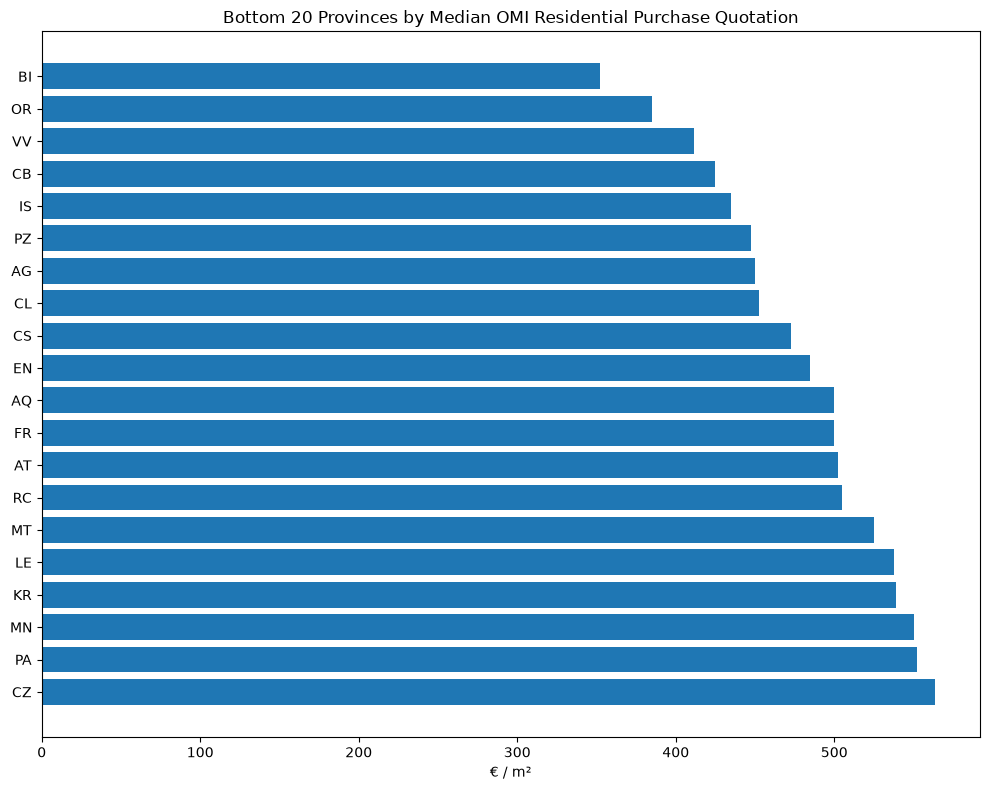

In [17]:
last_provinces = (
    provincial_trend[
        provincial_trend['reference_date'].eq(latest_date)
    ]
    .nsmallest(20, 'median_compr_mid')
    .sort_values('median_compr_mid', ascending=False)
)

fig, ax = plt.subplots(figsize=(10, 8))

ax.barh(
    last_provinces['Prov'],
    last_provinces['median_compr_mid']
)

ax.set_title('Bottom 20 Provinces by Median OMI Residential Purchase Quotation')
ax.set_xlabel('€ / m²')
ax.set_ylabel('')

fig.tight_layout()

plt.show()

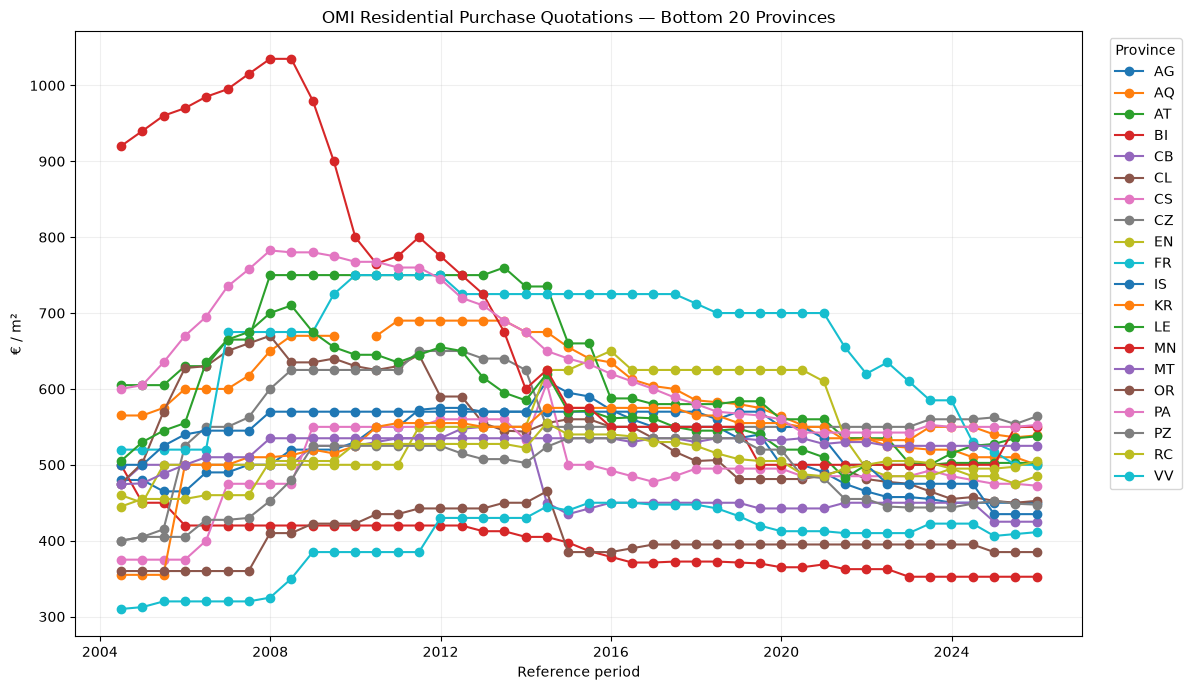

In [18]:
last_provinces_names = (
    provincial_trend[
        provincial_trend['reference_date'].eq(latest_date)
    ]
    .nsmallest(20, 'median_compr_mid')['Prov']
)

plot_data = provincial_trend[
    provincial_trend['Prov'].isin(last_provinces_names)
]

fig, ax = plt.subplots(figsize=(12, 7))

for provincia, data in plot_data.groupby('Prov'):
    ax.plot(
        data['reference_date'],
        data['median_compr_mid'],
        marker='o',
        linewidth=1.5,
        label=provincia
    )

ax.set_title('OMI Residential Purchase Quotations — Bottom 20 Provinces')
ax.set_xlabel('Reference period')
ax.set_ylabel('€ / m²')
ax.grid(alpha=0.2)

ax.legend(
    title='Province',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

fig.tight_layout()

plt.show()

#### Municipal Inspection

In [19]:
municipal_trend = (
    residential
    .groupby(['reference_date', 'Comune_descrizione'], as_index=False)
    .agg(
        median_compr_mid=('Compr_mid', 'median'),
        mean_compr_mid=('Compr_mid', 'mean'),
        observations=('Compr_mid', 'count')
    )
)

latest_date = municipal_trend['reference_date'].max()

##### Top 20

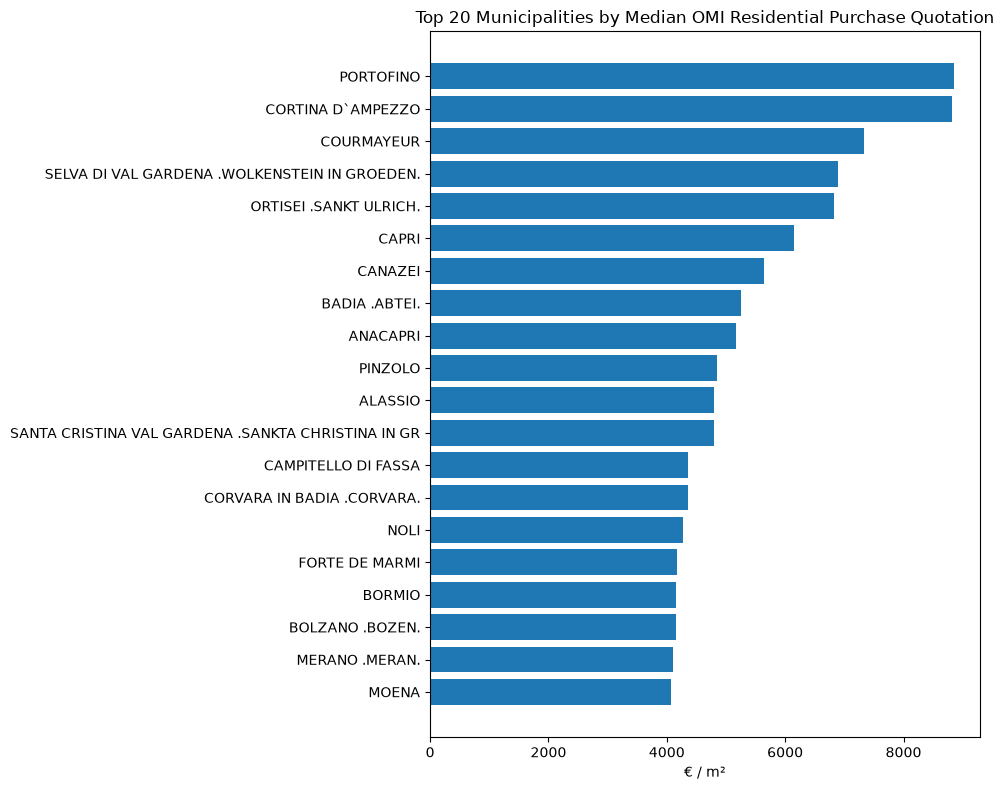

In [20]:
top_municipalities = (
    municipal_trend[
        municipal_trend['reference_date'].eq(latest_date)
    ]
    .nlargest(20, 'median_compr_mid')
    .sort_values('median_compr_mid')
)

fig, ax = plt.subplots(figsize=(10, 8))

ax.barh(
    top_municipalities['Comune_descrizione'],
    top_municipalities['median_compr_mid']
)

ax.set_title('Top 20 Municipalities by Median OMI Residential Purchase Quotation')
ax.set_xlabel('€ / m²')
ax.set_ylabel('')

fig.tight_layout()

plt.show()

In [23]:
municipal_trend = (
    residential.groupby(['reference_date', "Comune_descrizione"], as_index=False)
    .agg(median_compr_mid=('Compr_mid','median'), mean_compr_mid=('Compr_mid','mean'), observations=('Compr_mid','count'))
)

display(municipal_trend.tail(10))

,reference_date,Comune_descrizione,median_compr_mid,mean_compr_mid,observations
352366,2025-12-31,ZOPPOLA,700.00,696.875,8
352367,2025-12-31,ZOVENCEDO,937.50,860.000,4
352368,2025-12-31,ZUBIENA,336.25,358.125,4
352369,2025-12-31,ZUCCARELLO,1425.00,1425.000,1
352370,2025-12-31,ZUGLIANO,1087.50,1096.250,8
352371,2025-12-31,ZUGLIO,545.00,565.000,3
352372,2025-12-31,ZUMAGLIA,347.50,347.500,2
352373,2025-12-31,ZUMPANO,610.00,612.000,5
352374,2025-12-31,ZUNGOLI,451.25,461.250,8
352375,2025-12-31,ZUNGRI,351.25,351.250,2


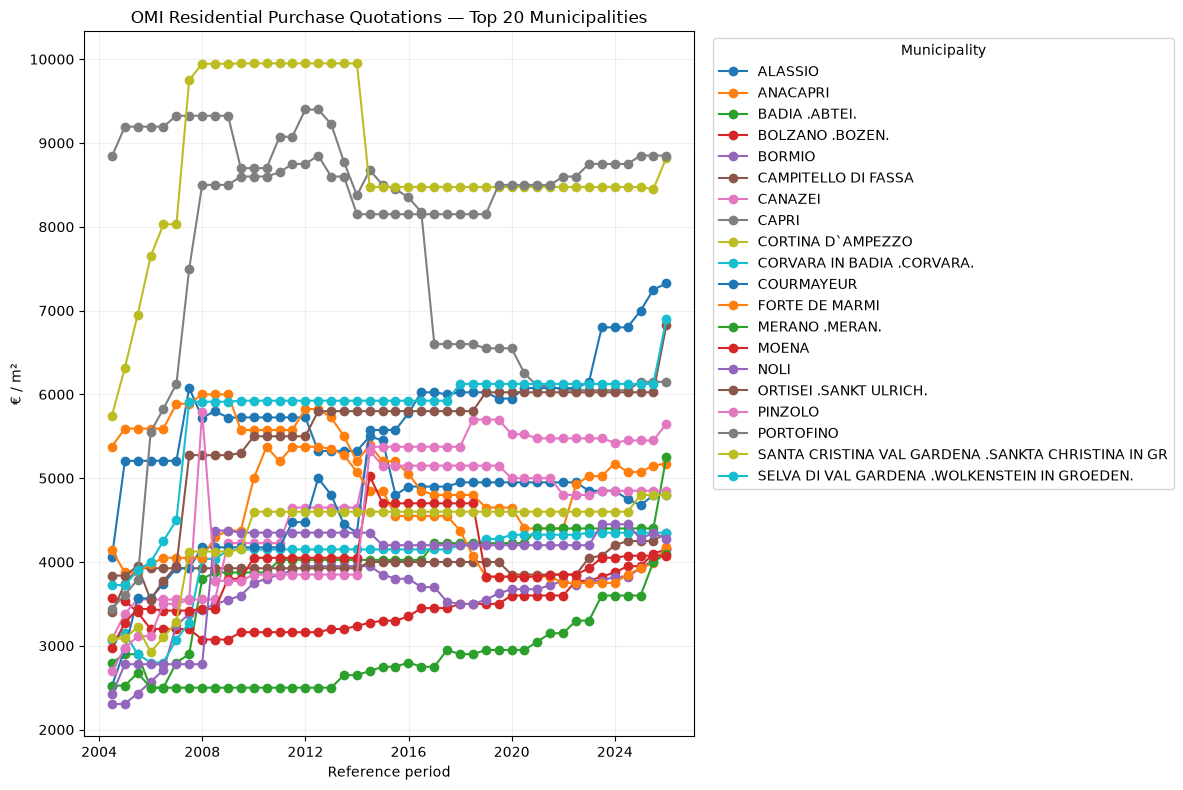

In [24]:
top_municipalities_names = (
    municipal_trend[
        municipal_trend['reference_date'].eq(latest_date)
    ]
    .nlargest(20, 'median_compr_mid')['Comune_descrizione']
)

plot_data = municipal_trend[
    municipal_trend['Comune_descrizione'].isin(top_municipalities_names)
]

fig, ax = plt.subplots(figsize=(12, 8))

for comune, data in plot_data.groupby('Comune_descrizione'):
    ax.plot(
        data['reference_date'],
        data['median_compr_mid'],
        marker='o',
        linewidth=1.5,
        label=comune
    )

ax.set_title('OMI Residential Purchase Quotations — Top 20 Municipalities')
ax.set_xlabel('Reference period')
ax.set_ylabel('€ / m²')
ax.grid(alpha=0.2)

ax.legend(
    title='Municipality',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

fig.tight_layout()

plt.show()

##### Last 20

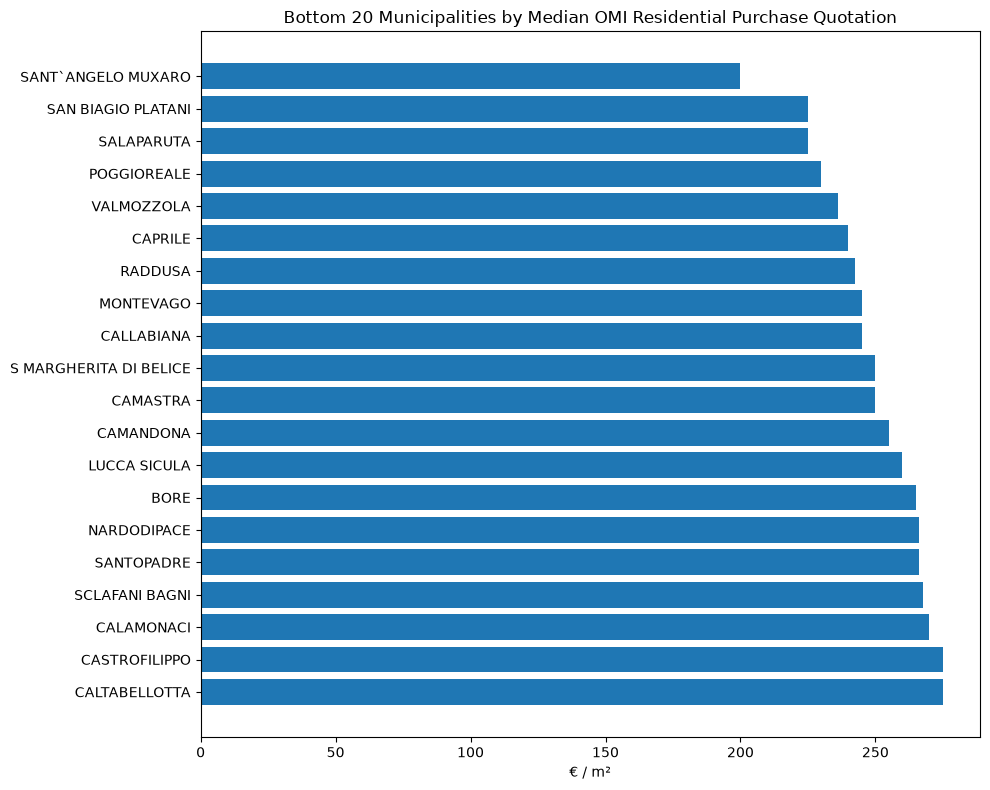

In [25]:
last_municipalities = (
    municipal_trend[
        municipal_trend['reference_date'].eq(latest_date)
    ]
    .nsmallest(20, 'median_compr_mid')
    .sort_values('median_compr_mid', ascending=False)
)

fig, ax = plt.subplots(figsize=(10, 8))

ax.barh(
    last_municipalities['Comune_descrizione'],
    last_municipalities['median_compr_mid']
)

ax.set_title('Bottom 20 Municipalities by Median OMI Residential Purchase Quotation')
ax.set_xlabel('€ / m²')
ax.set_ylabel('')

fig.tight_layout()

plt.show()

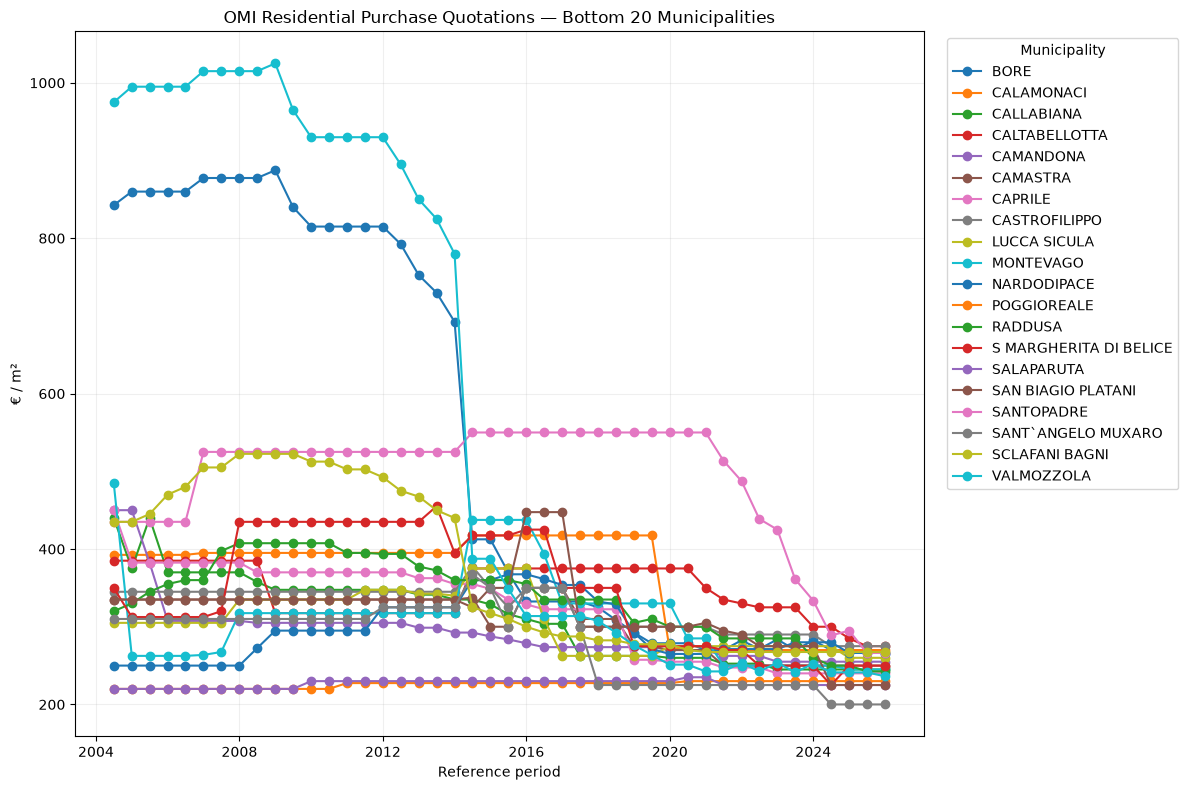

In [26]:
last_municipalities_names = (
    municipal_trend[
        municipal_trend['reference_date'].eq(latest_date)
    ]
    .nsmallest(20, 'median_compr_mid')['Comune_descrizione']
)

plot_data = municipal_trend[
    municipal_trend['Comune_descrizione'].isin(last_municipalities_names)
]

fig, ax = plt.subplots(figsize=(12, 8))

for comune, data in plot_data.groupby('Comune_descrizione'):
    ax.plot(
        data['reference_date'],
        data['median_compr_mid'],
        marker='o',
        linewidth=1.5,
        label=comune
    )

ax.set_title('OMI Residential Purchase Quotations — Bottom 20 Municipalities')
ax.set_xlabel('Reference period')
ax.set_ylabel('€ / m²')
ax.grid(alpha=0.2)

ax.legend(
    title='Municipality',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

fig.tight_layout()

plt.show()

#### Deeper Inspection

##### Lombardia - Provinces

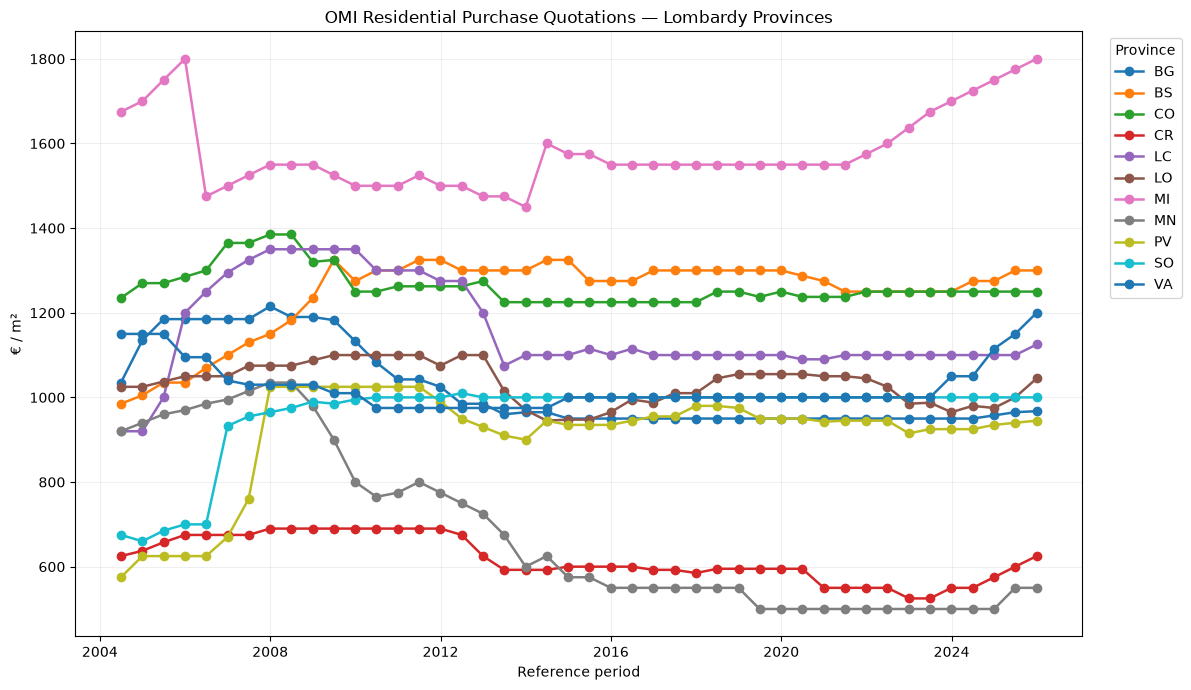

In [27]:
lombardia_trend = (
    residential[
        residential['Regione'].eq('LOMBARDIA')
    ]
    .groupby(
        ['reference_date', 'Prov'],
        as_index=False
    )
    .agg(
        median_compr_mid=('Compr_mid', 'median'),
        observations=('Compr_mid', 'count')
    )
)

fig, ax = plt.subplots(figsize=(12, 7))

for provincia, data in lombardia_trend.groupby('Prov'):
    ax.plot(
        data['reference_date'],
        data['median_compr_mid'],
        marker='o',
        linewidth=1.8,
        label=provincia
    )

ax.set_title('OMI Residential Purchase Quotations — Lombardy Provinces')
ax.set_xlabel('Reference period')
ax.set_ylabel('€ / m²')
ax.grid(alpha=0.2)

ax.legend(
    title='Province',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

fig.tight_layout()

plt.show()

##### Brescia - Municipialites

In [28]:
brescia_trend = (
    residential[
        residential['Prov'].eq('BS')
    ]
    .groupby(
        ['reference_date', 'Comune_descrizione'],
        as_index=False
    )
    .agg(
        median_compr_mid=('Compr_mid', 'median'),
        observations=('Compr_mid', 'count')
    )
)

latest_date = brescia_trend['reference_date'].max()

latest_brescia = (
    brescia_trend[
        brescia_trend['reference_date'].eq(latest_date)
    ]
    .sort_values('median_compr_mid', ascending=False)
)

top_10 = latest_brescia.head(10)['Comune_descrizione']

middle_10 = (
    latest_brescia
    .iloc[len(latest_brescia) // 2 - 5 : len(latest_brescia) // 2 + 5]
    ['Comune_descrizione']
)

last_10 = latest_brescia.tail(10)['Comune_descrizione']

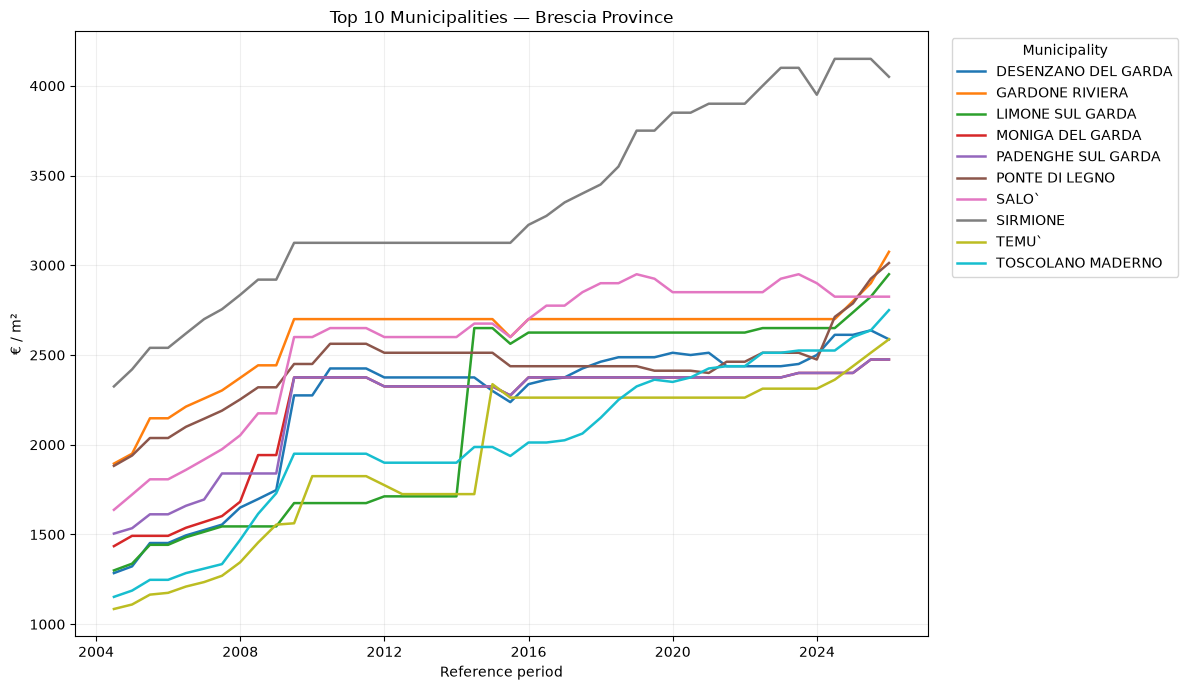

In [29]:
plot_data = brescia_trend[
    brescia_trend['Comune_descrizione'].isin(top_10)
]

fig, ax = plt.subplots(figsize=(12, 7))

for comune, data in plot_data.groupby('Comune_descrizione'):
    ax.plot(
        data['reference_date'],
        data['median_compr_mid'],
        linewidth=1.8,
        label=comune
    )

ax.set_title(
    'Top 10 Municipalities — Brescia Province'
)
ax.set_xlabel('Reference period')
ax.set_ylabel('€ / m²')
ax.grid(alpha=0.2)

ax.legend(
    title='Municipality',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

fig.tight_layout()
plt.show()

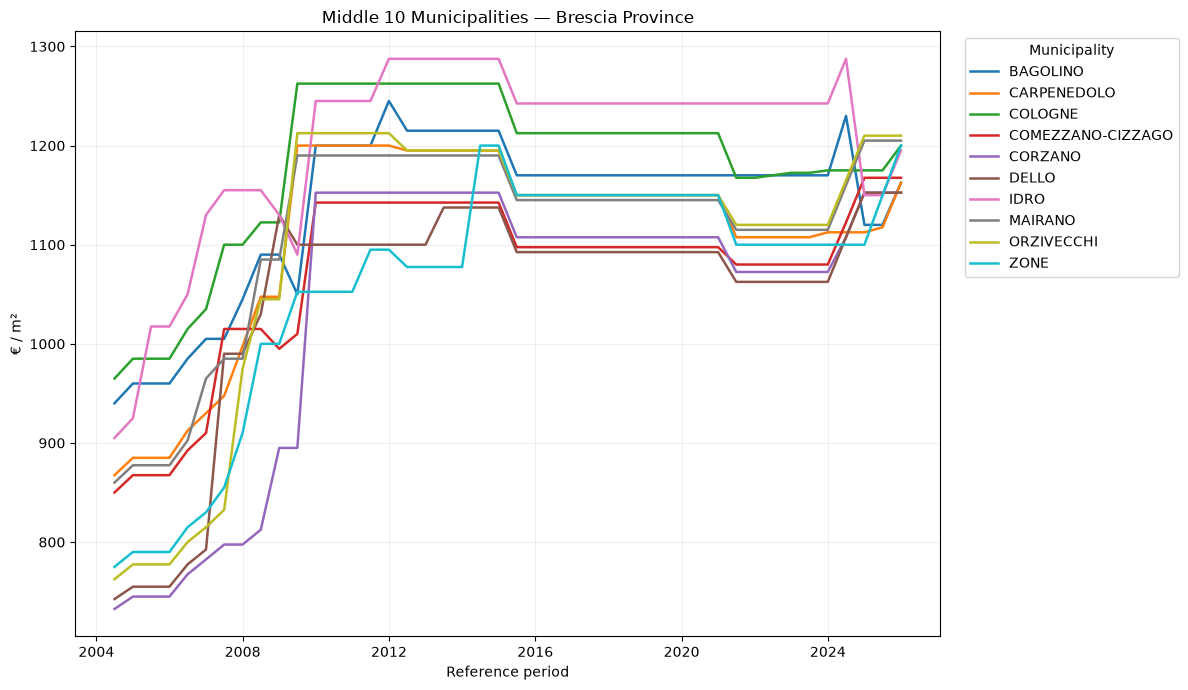

In [30]:
plot_data = brescia_trend[
    brescia_trend['Comune_descrizione'].isin(middle_10)
]

fig, ax = plt.subplots(figsize=(12, 7))

for comune, data in plot_data.groupby('Comune_descrizione'):
    ax.plot(
        data['reference_date'],
        data['median_compr_mid'],
        linewidth=1.8,
        label=comune
    )

ax.set_title(
    'Middle 10 Municipalities — Brescia Province'
)
ax.set_xlabel('Reference period')
ax.set_ylabel('€ / m²')
ax.grid(alpha=0.2)

ax.legend(
    title='Municipality',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

fig.tight_layout()
plt.show()

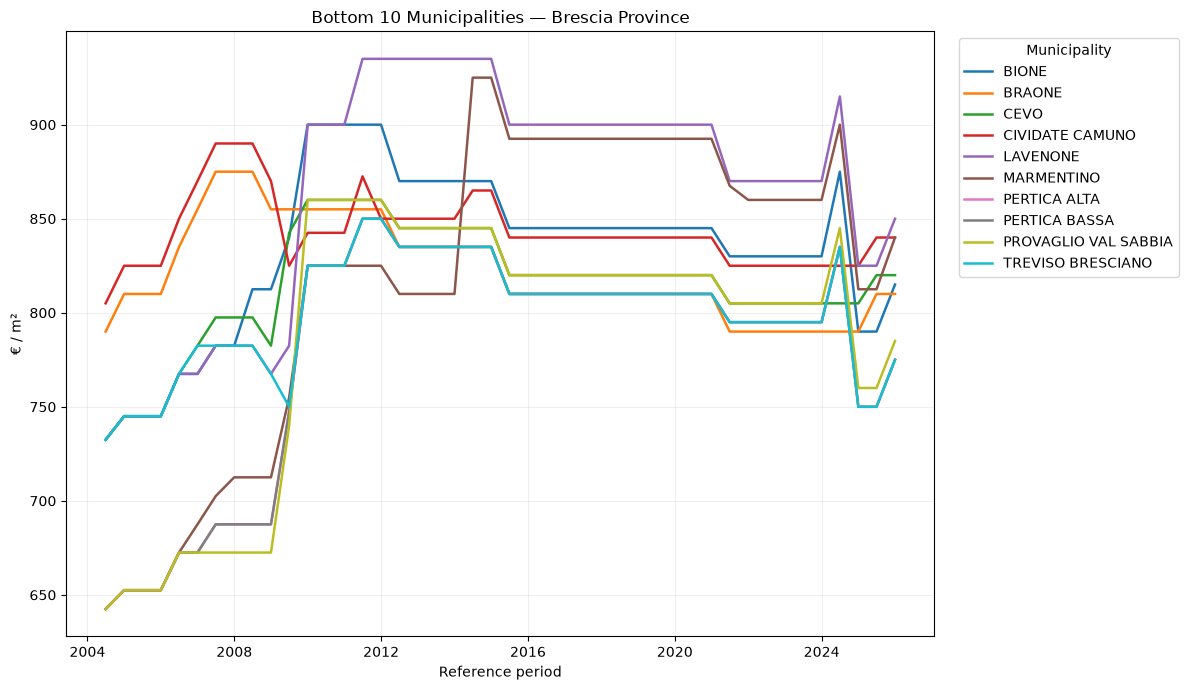

In [31]:
plot_data = brescia_trend[
    brescia_trend['Comune_descrizione'].isin(last_10)
]

fig, ax = plt.subplots(figsize=(12, 7))

for comune, data in plot_data.groupby('Comune_descrizione'):
    ax.plot(
        data['reference_date'],
        data['median_compr_mid'],
        linewidth=1.8,
        label=comune
    )

ax.set_title(
    'Bottom 10 Municipalities — Brescia Province'
)
ax.set_xlabel('Reference period')
ax.set_ylabel('€ / m²')
ax.grid(alpha=0.2)

ax.legend(
    title='Municipality',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

fig.tight_layout()
plt.show()

In [32]:
brescia_matrix = (
    residential[
        residential['Prov'].eq('BS')
    ]
    .assign(
        year=lambda x: x['reference_date'].dt.year
    )
    .groupby(
        ['Comune_descrizione', 'year'],
        as_index=False
    )
    .agg(
        median_compr_mid=('Compr_mid', 'median'),
        observations=('Compr_mid', 'count')
    )
)

# Matrice Comune × Anno
price_matrix = (
    brescia_matrix
    .pivot(
        index='Comune_descrizione',
        columns='year',
        values='median_compr_mid'
    )
)

# Classifica nell'ultimo anno disponibile
latest_year = price_matrix.columns.max()

ranking = (
    price_matrix[latest_year]
    .rank(
        method='min',
        ascending=False
    )
    .astype('Int64')
    .rename('rank_latest')
)

# Variazione percentuale tra primo e ultimo anno disponibile
first_year = price_matrix.columns.min()

change_pct = (
    (
        price_matrix[latest_year]
        / price_matrix[first_year]
        - 1
    ) * 100
).rename('change_pct')

# Tabella finale
brescia_matrix_final = (
    price_matrix
    .join(ranking)
    .join(change_pct)
    .sort_values('rank_latest')
)

brescia_matrix_final

,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,...,2018,2019,2020,2021,2022,2023,2024,2025,rank_latest,change_pct
Comune_descrizione,,,,,,,,,,,,,,,,,,,,,
SIRMIONE,2372.5,2540.0,2660.0,2795.0,2920.0,3125.0,3125.0,3125.0,3125.0,3125.0,...,3650.0,3800.0,3875.0,3900.0,4050.0,4025.0,4150.0,4100.0,1,72.813488
PONTE DI LEGNO,1910.0,2037.5,2122.5,2252.5,2320.0,2450.0,2562.5,2537.5,2512.5,2512.5,...,2437.5,2412.5,2400.0,2462.5,2512.5,2475.0,2750.0,2962.5,2,55.104712
GARDONE RIVIERA,1922.5,2147.5,2235.0,2337.5,2442.5,2700.0,2700.0,2700.0,2700.0,2700.0,...,2700.0,2700.0,2700.0,2700.0,2700.0,2700.0,2750.0,2950.0,3,53.446034
LIMONE SUL GARDA,1317.5,1442.5,1497.5,1545.0,1545.0,1675.0,1675.0,1687.5,1712.5,1712.5,...,2625.0,2625.0,2625.0,2625.0,2650.0,2650.0,2700.0,2875.0,4,118.216319
SALO`,1677.5,1807.5,1887.5,2012.5,2175.0,2600.0,2650.0,2650.0,2600.0,2600.0,...,2925.0,2887.5,2850.0,2850.0,2850.0,2925.0,2825.0,2825.0,5,68.405365
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
PERTICA BASSA,647.5,652.5,672.5,687.5,687.5,815.0,825.0,850.0,835.0,835.0,...,810.0,810.0,810.0,795.0,795.0,795.0,792.5,762.5,201,17.760618
LONATO,1022.5,1080.0,1132.5,1192.5,1320.0,1425.0,1450.0,1437.5,1425.0,1450.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,NaN
MAGASA,647.5,652.5,680.0,715.0,725.0,815.0,815.0,815.0,815.0,850.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,NaN


In [33]:
observations_matrix = (
    brescia_matrix
    .pivot(
        index='Comune_descrizione',
        columns='year',
        values='observations'
    )
)

display(
    observations_matrix.style.format('{:,.0f}')
)

year,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
Comune_descrizione,,,,,,,,,,,,,,,,,,,,,,
ACQUAFREDDA,4,4,3,2,2,3,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4
ADRO,10,10,9,8,8,11,14,14,14,14,8,8,8,8,8,8,8,8,8,8,8,8
AGNOSINE,4,4,3,2,2,3,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4
ALFIANELLO,4,4,3,2,2,3,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4
ANFO,4,4,3,2,2,3,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4
ANGOLO TERME,4,4,4,4,4,6,8,8,8,8,6,6,6,6,6,6,6,6,6,6,6,6
ARTOGNE,6,6,6,6,6,9,12,12,12,12,9,8,8,8,8,8,8,8,8,8,8,8
AZZANO MELLA,4,4,3,2,3,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4
BAGNOLO MELLA,6,6,6,6,9,12,12,12,12,12,8,8,8,8,8,8,8,8,8,8,8,8


In [34]:
summary = pd.DataFrame({
    'latest_price': price_matrix[latest_year],
    'rank_latest': ranking,
    'first_price': price_matrix[first_year],
    'change_pct': change_pct,
    'observations_latest': observations_matrix[latest_year]
})

summary = summary.sort_values('rank_latest')

display(
    summary.style.format({
        'latest_price': '€ {:,.0f}',
        'first_price': '€ {:,.0f}',
        'rank_latest': '{:.0f}',
        'change_pct': '{:+.1f}%',
        'observations_latest': '{:,.0f}'
    })
)

,latest_price,rank_latest,first_price,change_pct,observations_latest
Comune_descrizione,,,,,
SIRMIONE,"€ 4,100",1,"€ 2,372",+72.8%,18
PONTE DI LEGNO,"€ 2,962",2,"€ 1,910",+55.1%,24
GARDONE RIVIERA,"€ 2,950",3,"€ 1,922",+53.4%,22
LIMONE SUL GARDA,"€ 2,875",4,"€ 1,318",+118.2%,12
SALO`,"€ 2,825",5,"€ 1,678",+68.4%,18
TOSCOLANO MADERNO,"€ 2,688",6,"€ 1,170",+129.7%,12
DESENZANO DEL GARDA,"€ 2,588",7,"€ 1,302",+98.7%,28
TEMU`,"€ 2,550",8,"€ 1,090",+133.9%,12
PADENGHE SUL GARDA,"€ 2,475",9,"€ 1,520",+62.8%,18
